In [ ]:
import pandas as pd # for manipulating data 
import numpy as np # math calcuations
import matplotlib.pyplot as plt # drawing chart
import seaborn as sns # graphs 



In [ ]:
dataframe = pd.read_csv("C:/Users/bsanj/Desktop/data analyst/python projects/Zomato-data-.csv") # we need change \to / run file path
print(dataframe.head()) # we can use df.head  print out the file 5 rows of data 

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [ ]:
def handleRate(value): #create a funtion 
    value=str(value).split('/') #rate value was split 
    value=value[0];#it return very first item from list 
    return float(value) #converts the text 

dataframe['rate']=dataframe['rate'].apply (handleRate) # it apply 
print(dataframe.head()) # so it clean the rate table 4.1/5=4.1 

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [ ]:
dataframe.info()# gives you quick summary of dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [7]:
# Checking for missing/null values in each column
print(dataframe.isnull().sum())


name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


Text(0.5, 0, 'Type of restaurant')

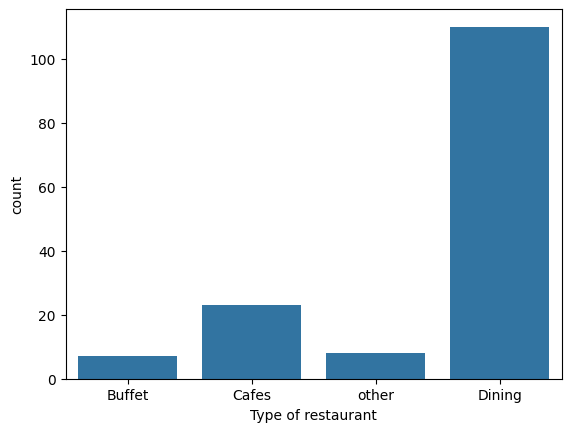

In [ ]:
sns.countplot(x=dataframe['listed_in(type)']) #counts how many time each category appears and draws bar chart 
plt.xlabel("Type of restaurant") # use to label 

Text(0, 0.5, 'Votes')

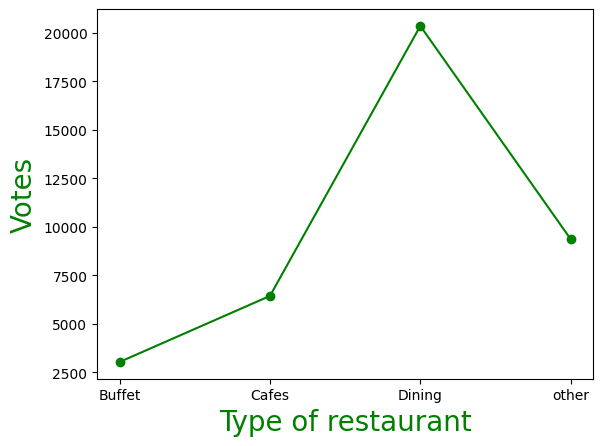

In [ ]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum() #groups all similar restaurants together and adds up sum() their votes .
result = pd.DataFrame({'votes': grouped_data})#
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant', c='green', size=20)
plt.ylabel('Votes', c='green', size=20)

In [12]:
max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


<Axes: xlabel='online_order', ylabel='count'>

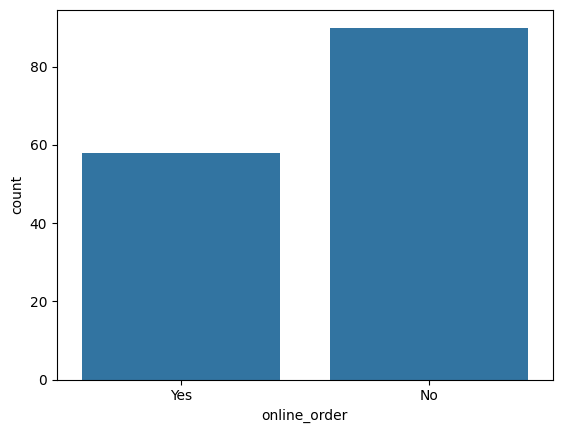

In [13]:
sns.countplot(x=dataframe['online_order'])

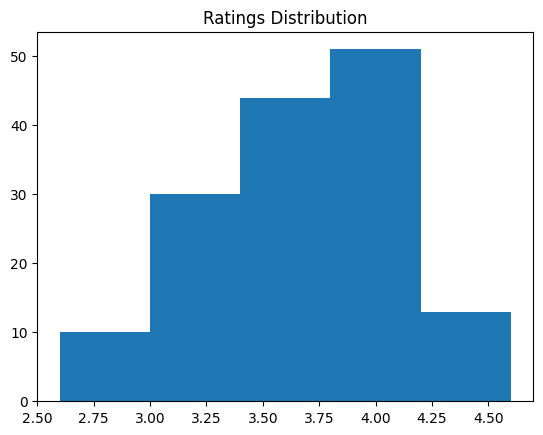

In [14]:
plt.hist(dataframe['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

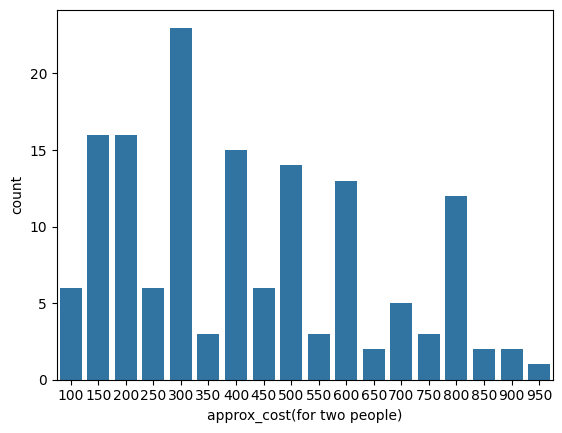

In [15]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

<Axes: xlabel='online_order', ylabel='rate'>

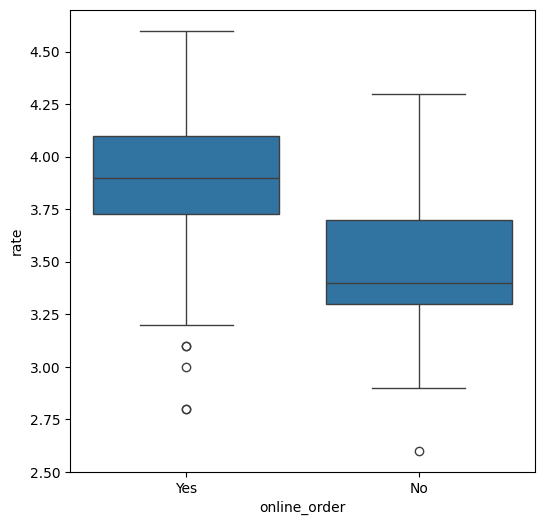

In [16]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = dataframe)

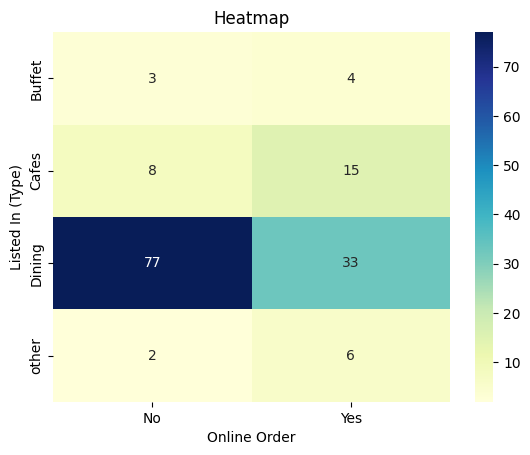

In [17]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()